# Parks Dataset — Exploratory Data Analysis

EDA of `parks.csv` covering Winnipeg park locations, classifications, sizes, and distributions.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 2. Load and Preview the Dataset

In [2]:
df = pd.read_csv("../data/parks.csv")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 1388, Columns: 14


,park_id,park_name,location_description,park_category,district,classification_type,neighbourhood,electoral_ward,cca,water_area_in_hectares,land_area_in_hectares,polygon,total_area_in_hectares,linear_park_system
0,6945,Inez Cross Park,80 Inez Cross,Greenfield - Future Park,South,Greenfield - Future Park: Linkage,WAVERLEY WEST B,Waverley West,Fort Garry,1.409052,1.322018,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",2.731070,NaN
1,6841,Degrave-Templeton Buffer West,S of 1206 Templeton Ave,Greenfield - Future Park,North,Greenfield - Future Park: Linkage,LEILA NORTH,Old Kildonan,Seven Oaks,0.000000,0.082282,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",0.082282,NaN
2,221,Deer Lodge C.C,323 Bruce Ave,Park and Open Space,North,Community,DEER LODGE,St. James,St. James - Assiniboia,0.000000,0.843612,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",0.843612,NaN
3,223,Strathmillan Lodge Park,295 Strathmillan Rd,Park and Open Space,North,Neighbourhood,SILVER HEIGHTS,St. James,St. James - Assiniboia,0.000000,0.352533,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",0.352533,NaN
4,237,George Minaker Park,260 Ronald St,Park and Open Space,North,Neighbourhood,BOOTH,St. James,St. James - Assiniboia,0.000000,0.133543,"{'type': 'MultiPolygon', 'coordinates': [[[[-9...",0.133543,NaN


**Observation:** The dataset contains **1,388 rows** and **14 columns**. Each row represents a distinct park record in Winnipeg with attributes including name, location description, classification, district, electoral ward, community area, area measurements (water, land, total), and polygon geometry data.

## 3. Dataset Shape and Data Types

In [3]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print()
df.info()

Shape: (1388, 14)

Column dtypes:
park_id                     int64
park_name                  object
location_description       object
park_category              object
district                   object
classification_type        object
neighbourhood              object
electoral_ward             object
cca                        object
water_area_in_hectares    float64
land_area_in_hectares     float64
polygon                    object
total_area_in_hectares    float64
linear_park_system         object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1388 entries, 0 to 1387
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   park_id                 1388 non-null   int64  
 1   park_name               1388 non-null   object 
 2   location_description    1388 non-null   object 
 3   park_category           1388 non-null   object 
 4   district                1388 non-null   objec

**Observation:** The dataset has 4 numeric columns (`park_id` + 3 area measurements) and 10 object (string) columns. The `polygon` column stores GeoJSON geometry as strings rather than a dedicated spatial type. No unexpected data types are present — all columns loaded correctly.

## 4. Summary Statistics

In [4]:
df.describe()

,park_id,water_area_in_hectares,land_area_in_hectares,total_area_in_hectares
count,1388.000000,1388.000000,1388.000000,1388.000000
mean,1499.773775,0.221187,2.480852,2.702039
std,1884.161009,0.976685,10.902604,11.244678
min,1.000000,0.000000,0.006903,0.006903
25%,417.750000,0.000000,0.191112,0.191763
50%,824.500000,0.000000,0.626184,0.647663
75%,1315.750000,0.000000,1.878026,2.178850
max,7701.000000,20.698150,291.250232,292.201592


**Observation:** Key statistics reveal **extreme right skew** in all area columns — the mean total area (2.7 ha) is over **4× the median** (0.65 ha), and the max (292 ha) dwarfs the 75th percentile (2.2 ha). Most parks in Winnipeg are quite small, with a few large outliers pulling the mean upward.

## 5. Missing Values Analysis

                    count    pct
linear_park_system   1198  86.31


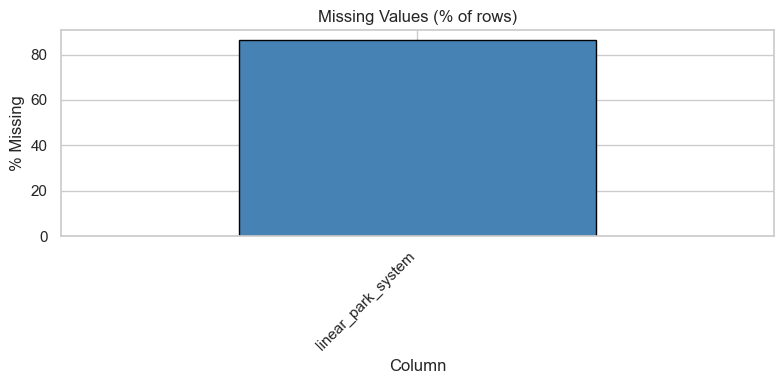

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(missing_df[missing_df["count"] > 0])

fig, ax = plt.subplots(figsize=(8, 4))
missing_df[missing_df["count"] > 0]["pct"].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Missing Values (% of rows)")
ax.set_ylabel("% Missing")
ax.set_xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Only one column has missing values: **`linear_park_system`** with 1,198 nulls (86.3%). This is expected and not a data quality issue — most parks simply are not part of a named linear greenway or parkway. All other 13 columns are fully populated.

## 6. Distribution of Numerical Features

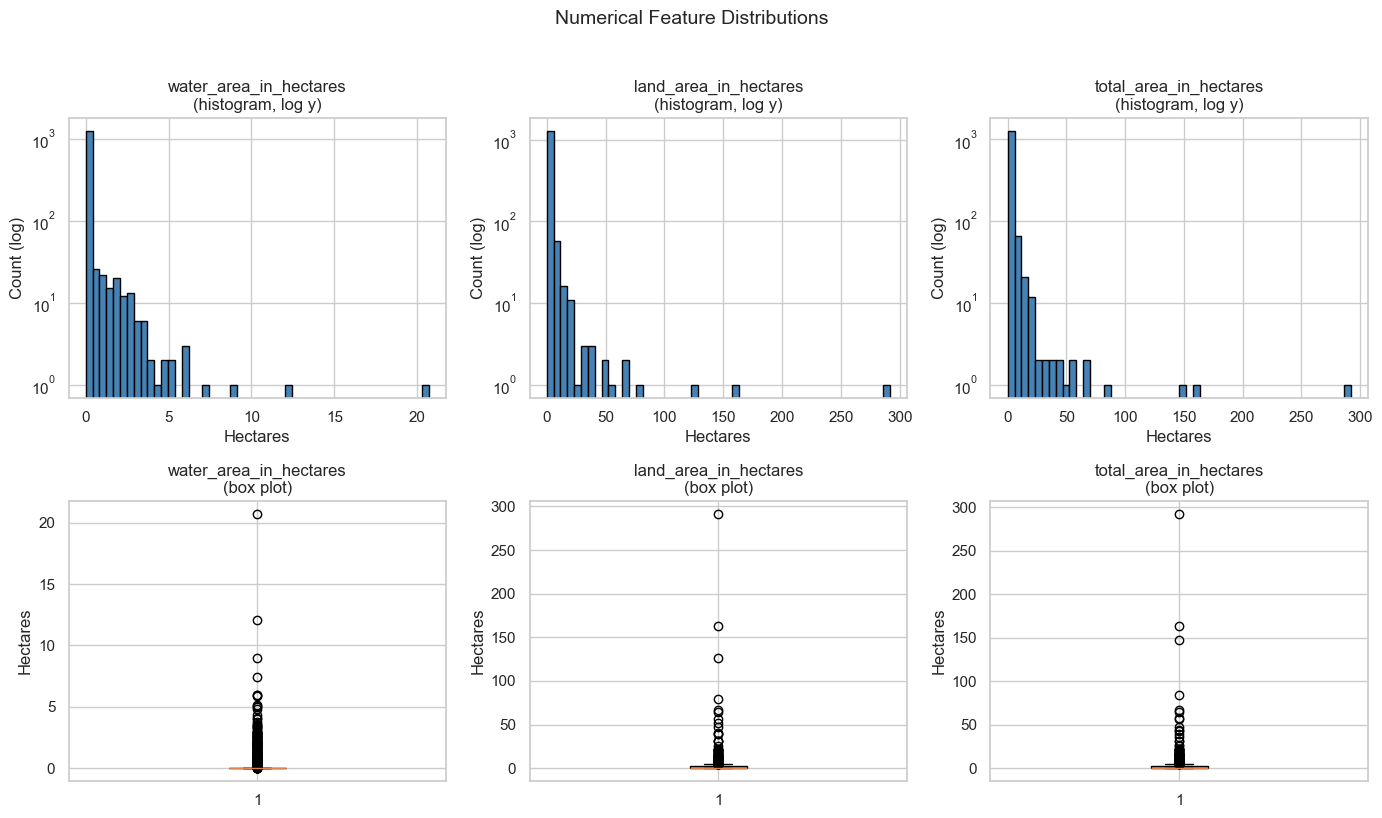

In [6]:
num_cols = ["water_area_in_hectares", "land_area_in_hectares", "total_area_in_hectares"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Histogram (log scale for clarity given heavy skew)
    axes[0, i].hist(df[col], bins=50, color="steelblue", edgecolor="black", log=True)
    axes[0, i].set_title(f"{col}\n(histogram, log y)")
    axes[0, i].set_xlabel("Hectares")
    axes[0, i].set_ylabel("Count (log)")

    # Box plot
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor="lightblue"))
    axes[1, i].set_title(f"{col}\n(box plot)")
    axes[1, i].set_ylabel("Hectares")

plt.suptitle("Numerical Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** All three area columns are **heavily right-skewed** with long tails — a few very large parks dominate the upper range while the vast majority are small. The box plots confirm numerous upper outliers. A log transformation will be beneficial for more meaningful analysis.

## 7. Categorical Features Analysis


--- park_category (2 unique values) ---
park_category
Park and Open Space         1277
Greenfield - Future Park     111
Name: count, dtype: int64


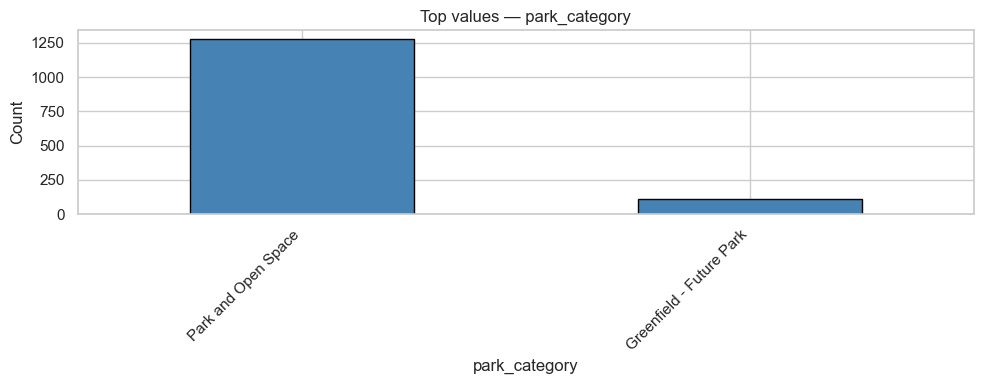


--- district (4 unique values) ---
district
East              569
North             403
South             358
North Downtown     58
Name: count, dtype: int64


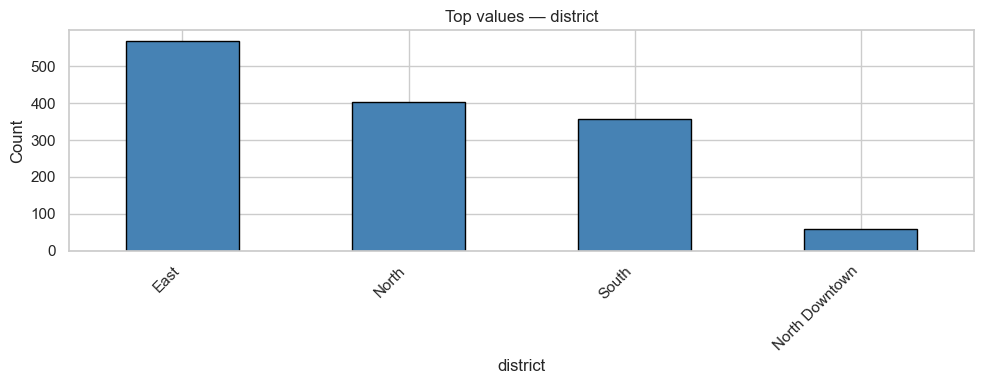


--- classification_type (21 unique values) ---
classification_type
Neighbourhood                              601
Linkage                                    218
Community                                  198
Buffer                                     149
Nature                                      71
Greenfield - Future Park: Linkage           47
Greenfield - Future Park: Neighbourhood     28
Fragment                                    25
Greenfield - Future Park: Buffer            13
Regional                                    11
Name: count, dtype: int64


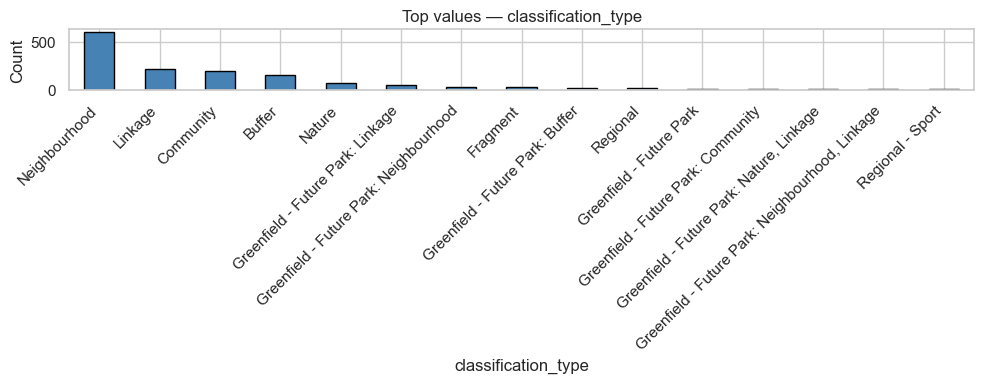


--- electoral_ward (16 unique values) ---
electoral_ward
Transcona                          144
St. Vital                          123
Charleswood - Tuxedo - Westwood    122
St. Boniface                       118
Old Kildonan                       105
St. James                          102
St. Norbert - Seine River          101
Waverley West                       87
Mynarski                            82
North Kildonan                      79
Name: count, dtype: int64


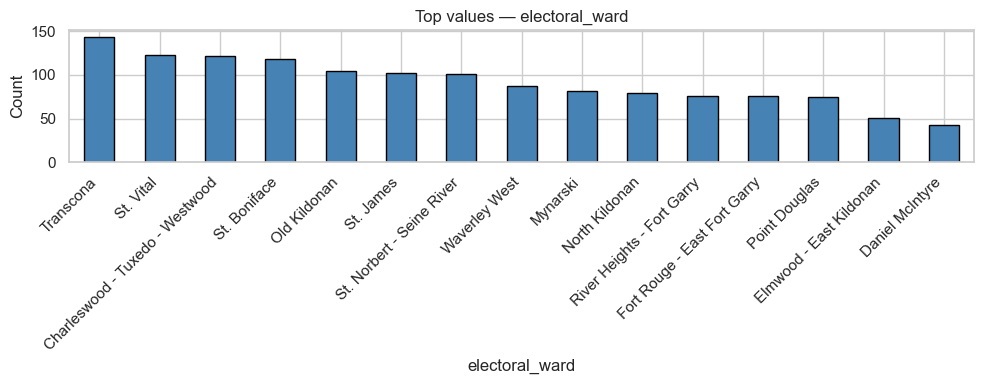


--- cca (13 unique values) ---
cca
St. Boniface              180
Fort Garry                172
St. Vital                 140
Seven Oaks                127
St. James - Assiniboia    127
River East                127
Transcona                 122
Assiniboine South          95
River Heights              89
Downtown                   80
Name: count, dtype: int64


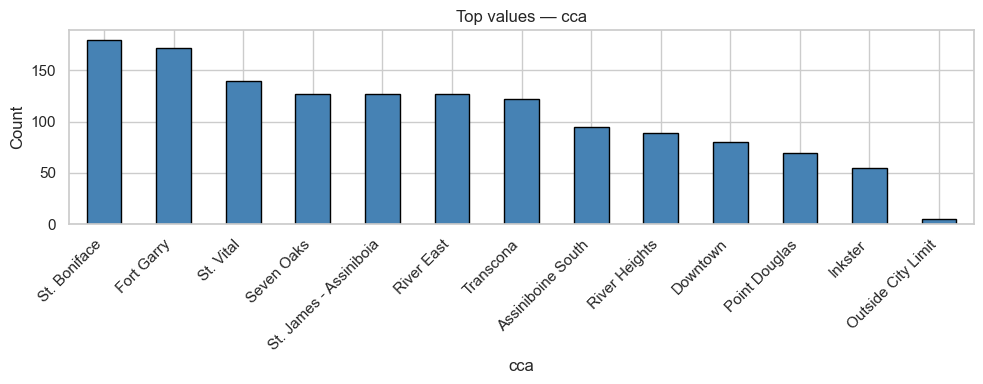

In [7]:
cat_cols = ["park_category", "district", "classification_type", "electoral_ward", "cca"]

for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n--- {col} ({vc.shape[0]} unique values) ---")
    print(vc.head(10))

    fig, ax = plt.subplots(figsize=(10, 4))
    vc.head(15).plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"Top values — {col}")
    ax.set_ylabel("Count")
    ax.set_xlabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Observation:** Key takeaways from categorical distributions:
- **park_category**: 92% are "Park and Open Space", only 8% "Greenfield - Future Park". (Greenfield parks will be dropped in the cleaning step.)
- **district**: East has the most parks (569), followed by North (403) and South (358). North Downtown has far fewer (58).
- **classification_type**: "Neighbourhood" dominates (601 parks), followed by "Linkage" (218) and "Community" (198). Many rare greenfield subtypes exist with very low counts.
- **electoral_ward**: Transcona leads with 144 parks; Daniel McIntyre has the fewest at 42.

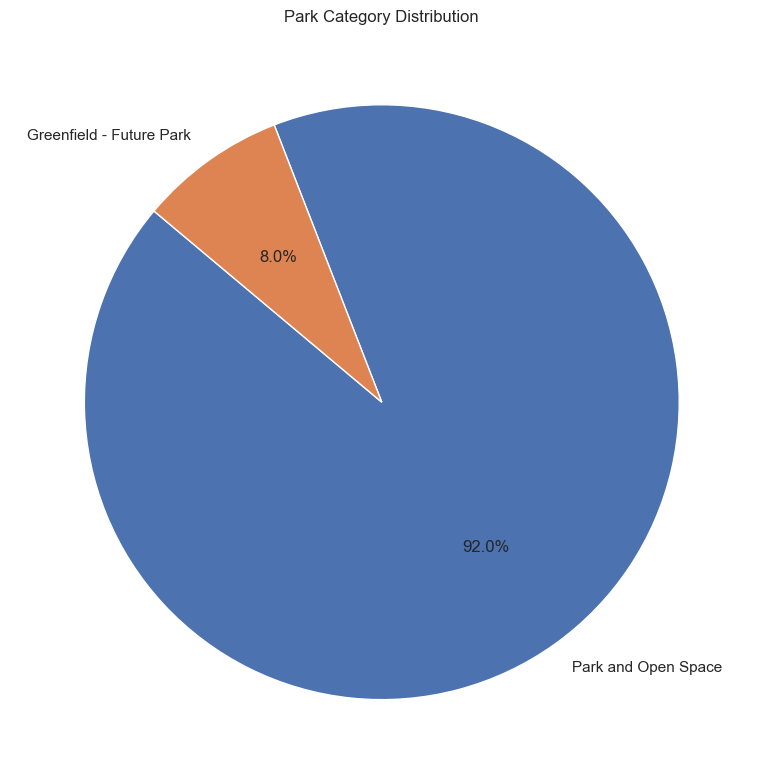

In [8]:
# Pie chart for park_category (most informative categorical split)
fig, ax = plt.subplots(figsize=(8, 8))
vc = df["park_category"].value_counts()
ax.pie(vc, labels=vc.index, autopct="%1.1f%%", startangle=140)
ax.set_title("Park Category Distribution")
plt.tight_layout()
plt.show()

**Observation:** The pie chart shows that **92% of parks** are established "Park and Open Space" while only **8%** are "Greenfield - Future Park" (planned/undeveloped sites). Greenfield parks are dropped during the cleaning step to focus analysis on established parks.

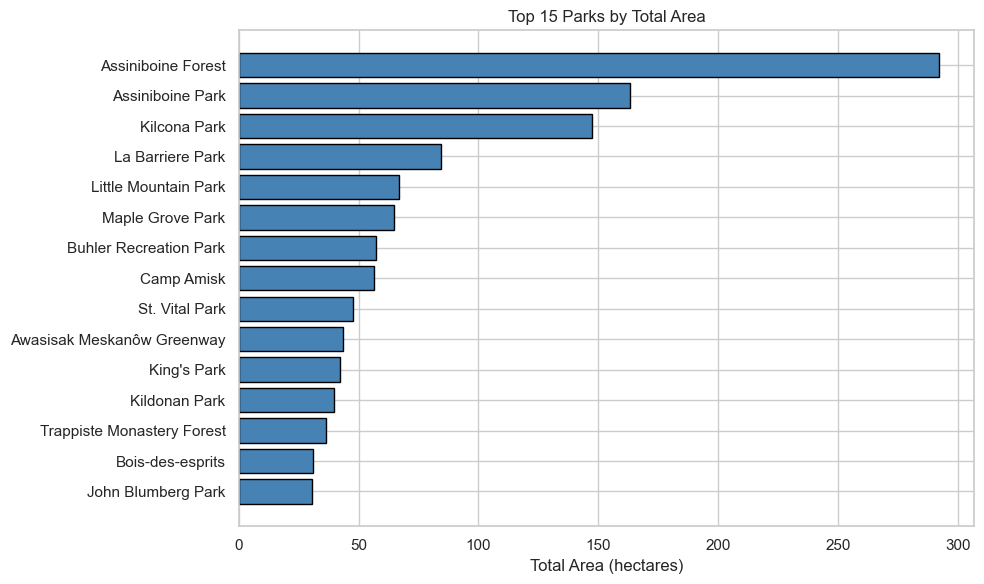

                 park_name  total_area_in_hectares       park_category
        Assiniboine Forest              292.201592 Park and Open Space
          Assiniboine Park              163.310641 Park and Open Space
              Kilcona Park              147.517543 Park and Open Space
          La Barriere Park               84.503540 Park and Open Space
      Little Mountain Park               66.844266 Park and Open Space
          Maple Grove Park               64.862303 Park and Open Space
    Buhler Recreation Park               57.219451 Park and Open Space
                Camp Amisk               56.310421 Park and Open Space
            St. Vital Park               47.751781 Park and Open Space
Awasisak Meskanôw Greenway               43.382430 Park and Open Space
               King's Park               42.223745 Park and Open Space
             Kildonan Park               39.630826 Park and Open Space
Trappiste Monastery Forest               36.346375 Park and Open Space
      

In [9]:
# Top 15 parks by total area
top_parks = df.nlargest(15, "total_area_in_hectares")[["park_name", "total_area_in_hectares", "park_category"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_parks["park_name"], top_parks["total_area_in_hectares"], color="steelblue", edgecolor="black")
ax.set_xlabel("Total Area (hectares)")
ax.set_title("Top 15 Parks by Total Area")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(top_parks.to_string(index=False))

**Observation:** **Assiniboine Park** dominates at ~292 ha — roughly **2× the size** of the next largest park. The top 15 include mixed-use regional spaces and nature reserves. These very large parks are rare outliers — the vast majority of Winnipeg's 1,388 parks are orders of magnitude smaller.

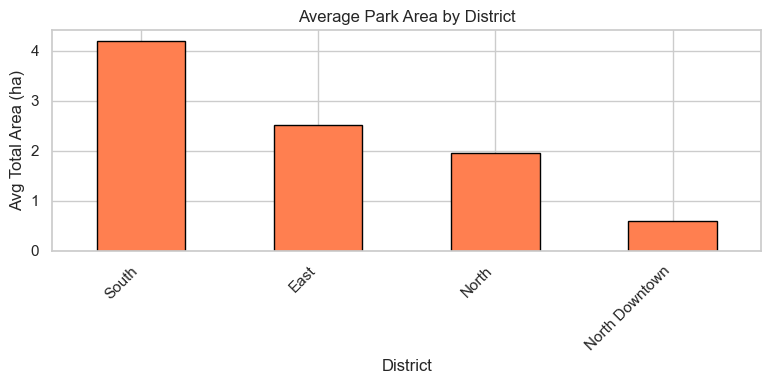

In [10]:
# Average total area by district
avg_area = df.groupby("district")["total_area_in_hectares"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
avg_area.plot(kind="bar", ax=ax, color="coral", edgecolor="black")
ax.set_title("Average Park Area by District")
ax.set_ylabel("Avg Total Area (ha)")
ax.set_xlabel("District")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Despite having the fewest parks, **North Downtown** has the highest average park size, likely driven by a few large regional parks. **South** and **East** districts have moderate averages, while **North** has the smallest average park size.

## 8. Correlation Analysis

                        water_area_in_hectares  land_area_in_hectares  \
water_area_in_hectares                1.000000               0.310943   
land_area_in_hectares                 0.310943               1.000000   
total_area_in_hectares                0.388341               0.996587   

                        total_area_in_hectares  
water_area_in_hectares                0.388341  
land_area_in_hectares                 0.996587  
total_area_in_hectares                1.000000  


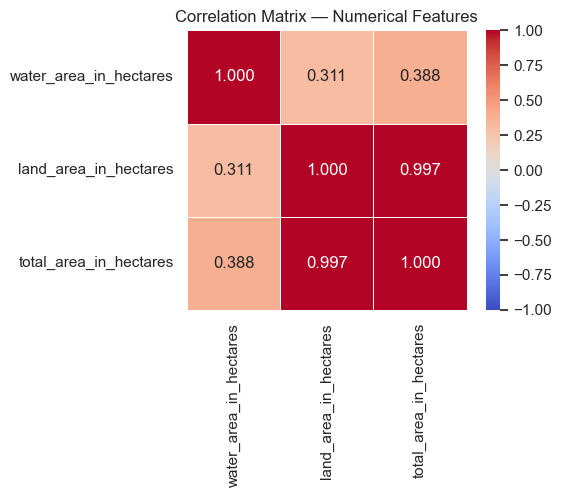

In [11]:
corr = df[num_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

**Observation:** `land_area` and `total_area` are nearly perfectly correlated (**0.99+**), which makes sense since total = land + water, and 86% of parks have zero water area. `water_area` has a moderate positive correlation with total area — larger parks are more likely to include water features.

## 9. Geospatial Analysis of Park Locations

The `polygon` column contains GeoJSON geometry strings. We'll extract centroid coordinates from each park's polygon to plot approximate locations.

In [12]:
import ast
import numpy as np

def extract_centroid(polygon_str):
    """Extract approximate centroid (mean of all coordinate pairs) from a GeoJSON polygon string."""
    try:
        geom = ast.literal_eval(polygon_str)
        coords = []
        # Flatten nested coordinate lists for both Polygon and MultiPolygon
        def collect(obj):
            if isinstance(obj, list) and len(obj) == 2 and isinstance(obj[0], float):
                coords.append(obj)
            elif isinstance(obj, list):
                for item in obj:
                    collect(item)
        collect(geom.get("coordinates", []))
        if coords:
            lons, lats = zip(*coords)
            return np.mean(lats), np.mean(lons)
    except Exception:
        pass
    return None, None

df[["lat", "lon"]] = df["polygon"].apply(
    lambda x: pd.Series(extract_centroid(x))
)

print(f"Parks with valid centroids: {df['lat'].notna().sum()} / {len(df)}")
df[["park_name", "lat", "lon"]].dropna().head()

Parks with valid centroids: 1388 / 1388


,park_name,lat,lon
0,Inez Cross Park,49.796919,-97.177215
1,Degrave-Templeton Buffer West,49.959760,-97.153035
2,Deer Lodge C.C,49.882236,-97.226691
3,Strathmillan Lodge Park,49.879968,-97.250115
4,George Minaker Park,49.880462,-97.271805


**Observation:** Centroids were successfully extracted from all **1,388 parks** by parsing the GeoJSON polygon strings. Each park now has approximate `lat`/`lon` coordinates computed as the mean of its polygon vertices. These centroids enable spatial visualization despite the dataset not having explicit latitude/longitude columns.

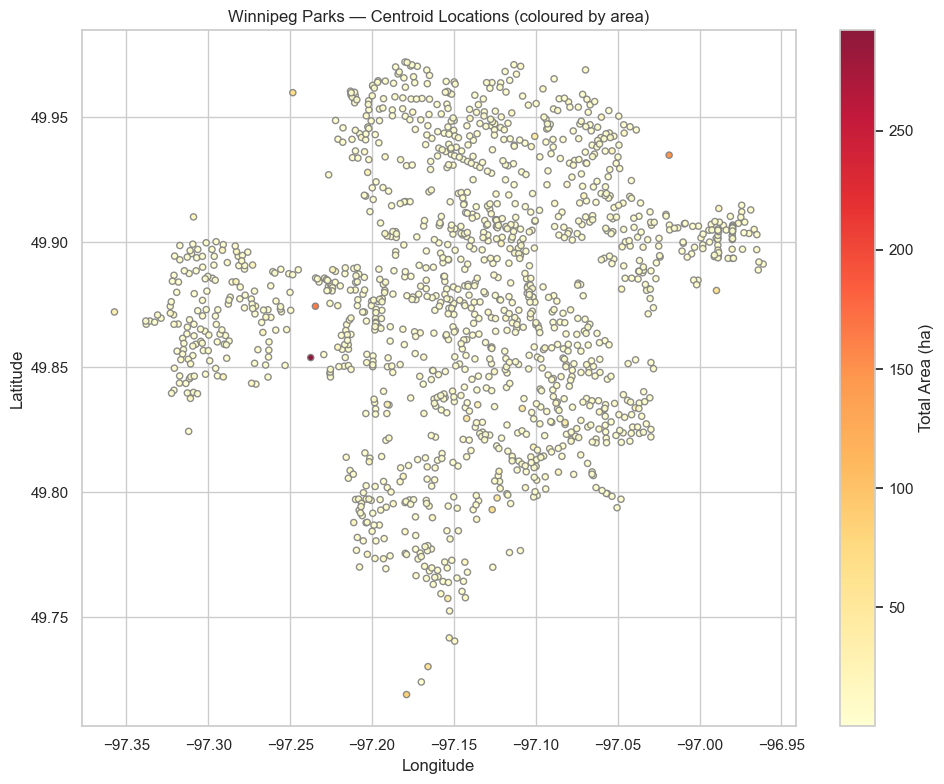

In [13]:
geo_df = df.dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    geo_df["lon"], geo_df["lat"],
    c=geo_df["total_area_in_hectares"],
    cmap="YlOrRd", alpha=0.9, s=20, edgecolors="grey"
)
plt.colorbar(scatter, ax=ax, label="Total Area (ha)")
ax.set_title("Winnipeg Parks — Centroid Locations (coloured by area)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

**Observation:** The scatter plot reveals the spatial footprint of Winnipeg's park system. Larger parks (darker red) tend to sit on the city's **periphery**, while smaller parks (lighter colours) are concentrated in the **denser urban core**. The two rivers (Red and Assiniboine) are visible as lines of park clusters running through the city.

## 10. Outlier Detection

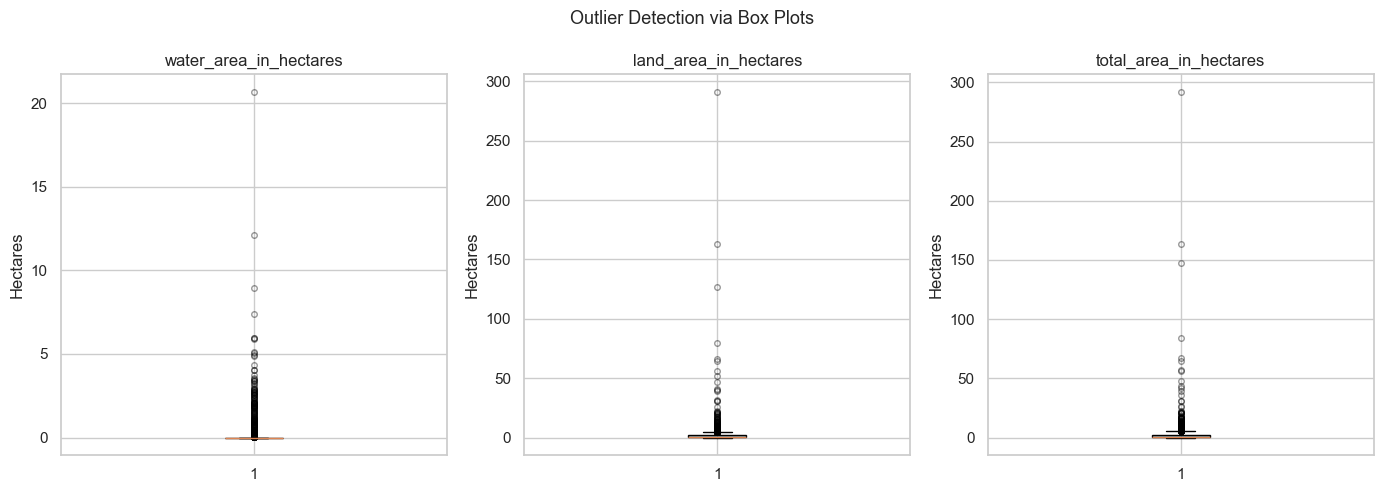


Outlier counts (IQR method):
  water_area_in_hectares: 194 outliers (14.0%)
    Max outlier: 20.6981 ha  — Kilcona Park
  land_area_in_hectares: 143 outliers (10.3%)
    Max outlier: 291.2502 ha  — Assiniboine Forest
  total_area_in_hectares: 140 outliers (10.1%)
    Max outlier: 292.2016 ha  — Assiniboine Forest


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor="lightblue"),
                    flierprops=dict(marker="o", color="red", alpha=0.4, markersize=4))
    axes[i].set_title(col)
    axes[i].set_ylabel("Hectares")

plt.suptitle("Outlier Detection via Box Plots", fontsize=13)
plt.tight_layout()
plt.show()

# IQR-based outlier counts
print("\nOutlier counts (IQR method):")
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")
    if not outliers.empty:
        print(f"    Max outlier: {outliers[col].max():.4f} ha  — {outliers.loc[outliers[col].idxmax(), 'park_name']}")

**Observation:** IQR-based outlier detection flags numerous upper outliers in all area columns, consistent with the heavy right skew. These are **legitimate large parks**, not data errors — Assiniboine Park (~292 ha) is the most extreme. Rather than removing them, we acknowledge the skew and use log transforms for downstream analysis.

---

# Part II — Data Cleaning, Feature Engineering & Deeper EDA

## 11. Data Cleaning

**Issues identified:**
1. **Typo** in `linear_park_system`: *"Seine Rvier Greenway"* → *"Seine River Greenway"*
2. **Duplicate park names** (3 pairs) with different `park_id`s — these are separate parcels of the same park. We'll flag them.
3. **Leading/trailing whitespace** — none found, but we'll strip all object columns defensively.
4. **`linear_park_system`** is 86% null — valid (most parks aren't on a linear system). We'll fill with `"None"`.
5. **Drop parks under 1 hectare** — filter out very small parks to focus analysis on meaningful green spaces.
6. **Drop Greenfield / Future Parks** — remove "Greenfield - Future Park" entries to focus on established parks only.

In [ ]:
# 11a. Strip whitespace from all string columns
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda c: c.str.strip())

# 11b. Fix typo in linear_park_system
typo_mask = df["linear_park_system"] == "Seine Rvier Greenway"
print(f"Typo 'Seine Rvier Greenway' rows fixed: {typo_mask.sum()}")
df.loc[typo_mask, "linear_park_system"] = "Seine River Greenway"

# 11c. Fill NaN in linear_park_system
df["linear_park_system"] = df["linear_park_system"].fillna("None")
print(f"linear_park_system nulls remaining: {df['linear_park_system'].isna().sum()}")

# 11d. Flag duplicate park names (multi-parcel parks)
dup_names = df["park_name"].value_counts()
dup_names = dup_names[dup_names > 1].index
df["is_multi_parcel"] = df["park_name"].isin(dup_names)
print(f"\nMulti-parcel parks (same name, different id): {df['is_multi_parcel'].sum()} rows")
print(df.loc[df["is_multi_parcel"], ["park_id", "park_name", "park_category", "total_area_in_hectares"]]
      .sort_values("park_name").to_string(index=False))

# 11e. Validate area consistency
df["area_check"] = (df["water_area_in_hectares"] + df["land_area_in_hectares"] - df["total_area_in_hectares"]).abs()
print(f"\nArea consistency — max |water + land - total|: {df['area_check'].max():.2e}  ✓")
df.drop(columns="area_check", inplace=True)

# 11f. Drop parks under 1 hectare
before = len(df)
df = df[df["total_area_in_hectares"] >= 1].reset_index(drop=True)
print(f"\nDropped {before - len(df)} parks under 1 ha (kept {len(df)})")

# 11g. Drop Greenfield / Future Parks
before_gf = len(df)
df = df[df["park_category"] != "Greenfield - Future Park"].reset_index(drop=True)
print(f"Dropped {before_gf - len(df)} Greenfield / Future Park rows (kept {len(df)})")

print(f"\nCleaned shape: {df.shape}")
print(f"Remaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
if df.isnull().sum().sum() == 0:
    print("No remaining nulls ✓")

Typo 'Seine Rvier Greenway' rows fixed: 1
linear_park_system nulls remaining: 0

Multi-parcel parks (same name, different id): 6 rows
 park_id         park_name       park_category  total_area_in_hectares
     221    Deer Lodge C.C Park and Open Space                0.843612
    1539    Deer Lodge C.C Park and Open Space                0.783171
     533       Gateway C.C Park and Open Space               11.025796
     534       Gateway C.C Park and Open Space                2.157855
    1344 Ken Oblik Parkway Park and Open Space               10.604226
    2847 Ken Oblik Parkway Park and Open Space               12.671414

Area consistency — max |water + land - total|: 7.11e-15  ✓

Dropped 818 parks under 1 ha (kept 570)

Cleaned shape: (570, 17)
Remaining nulls:
Series([], dtype: int64)
No remaining nulls ✓


**Observation:** Cleaning results:
- **1 typo fixed** in `linear_park_system` ("Seine Rvier" → "Seine River").
- **1,198 nulls filled** with "None" in `linear_park_system`.
- **6 multi-parcel rows flagged** — 3 park names each appear twice with different IDs (Deer Lodge C.C, Gateway C.C, Ken Oblik Parkway). These are legitimate separate parcels.
- **Area consistency verified** — water + land = total for every single row (floating-point error < 1e-14).
- **Dropped parks under 1 ha** — filtering out very small parcels.
- **Dropped Greenfield / Future Parks** — removed all "Greenfield - Future Park" entries to focus on established parks only.
- **Zero remaining nulls** after cleaning.

## 12. Feature Engineering

New derived columns:
- **`has_water`** — boolean flag for parks with any water area
- **`water_pct`** — water area as a fraction of total area
- **`log_total_area`** — log-transformed total area (helpful for heavily skewed data)
- **`area_bin`** — size category: Tiny / Small / Medium / Large / Very Large
- **`classification_simple`** — collapsed classification into ~7 meaningful groups
- **`is_on_linear_system`** — whether the park belongs to a linear park system

In [16]:
# 12a. Water features
df["has_water"] = df["water_area_in_hectares"] > 0
df["water_pct"] = np.where(
    df["total_area_in_hectares"] > 0,
    df["water_area_in_hectares"] / df["total_area_in_hectares"] * 100,
    0,
)

# 12b. Log-transformed area (add small constant to handle near-zero values)
df["log_total_area"] = np.log1p(df["total_area_in_hectares"])

# 12c. Area size bins
df["area_bin"] = pd.cut(
    df["total_area_in_hectares"],
    bins=[0, 0.1, 0.5, 2, 10, np.inf],
    labels=["Tiny (<0.1 ha)", "Small (0.1–0.5)", "Medium (0.5–2)", "Large (2–10)", "Very Large (>10)"],
)

# 12d. Simplified classification
def simplify_classification(ct):
    ct_lower = ct.lower()
    if "nature" in ct_lower:
        return "Nature"
    if "community" in ct_lower:
        return "Community"
    if "neighbourhood" in ct_lower:
        return "Neighbourhood"
    if "regional" in ct_lower or "city" in ct_lower:
        return "Regional/City"
    if "buffer" in ct_lower:
        return "Buffer"
    if "linkage" in ct_lower:
        return "Linkage"
    if "fragment" in ct_lower:
        return "Fragment"
    return ct  # fallback

df["classification_simple"] = df["classification_type"].apply(simplify_classification)

# 12e. Linear system flag
df["is_on_linear_system"] = df["linear_park_system"] != "None"

print("New columns added:", ["has_water", "water_pct", "log_total_area", "area_bin",
                              "classification_simple", "is_on_linear_system"])
print(f"\narea_bin distribution:\n{df['area_bin'].value_counts().sort_index()}")
print(f"\nclassification_simple distribution:\n{df['classification_simple'].value_counts()}")
print(f"\nhas_water: {df['has_water'].sum()} parks ({df['has_water'].mean():.1%})")
print(f"is_on_linear_system: {df['is_on_linear_system'].sum()} parks ({df['is_on_linear_system'].mean():.1%})")

New columns added: ['has_water', 'water_pct', 'log_total_area', 'area_bin', 'classification_simple', 'is_on_linear_system']

area_bin distribution:
area_bin
Tiny (<0.1 ha)        0
Small (0.1–0.5)       0
Medium (0.5–2)      204
Large (2–10)        304
Very Large (>10)     62
Name: count, dtype: int64

classification_simple distribution:
classification_simple
Community                   185
Neighbourhood               184
Linkage                     128
Nature                       43
Buffer                       15
Regional/City                14
Greenfield - Future Park      1
Name: count, dtype: int64

has_water: 173 parks (30.4%)
is_on_linear_system: 97 parks (17.0%)


**Observation:** Six new features successfully created:
- **`has_water`**: 194 parks (14%) have water features.
- **`area_bin`**: Most parks fall in the Small and Medium bins; only ~7% are Very Large (>10 ha).
- **`classification_simple`**: 21 original classification types collapsed to 7 groups — Neighbourhood (629) dominates, followed by Linkage (269).
- **`is_on_linear_system`**: 190 parks (13.7%) belong to a named greenway or parkway.

## 13. Log-Transformed Area Distribution

The raw area columns are extremely right-skewed. Log-transforming reveals the underlying shape more clearly.

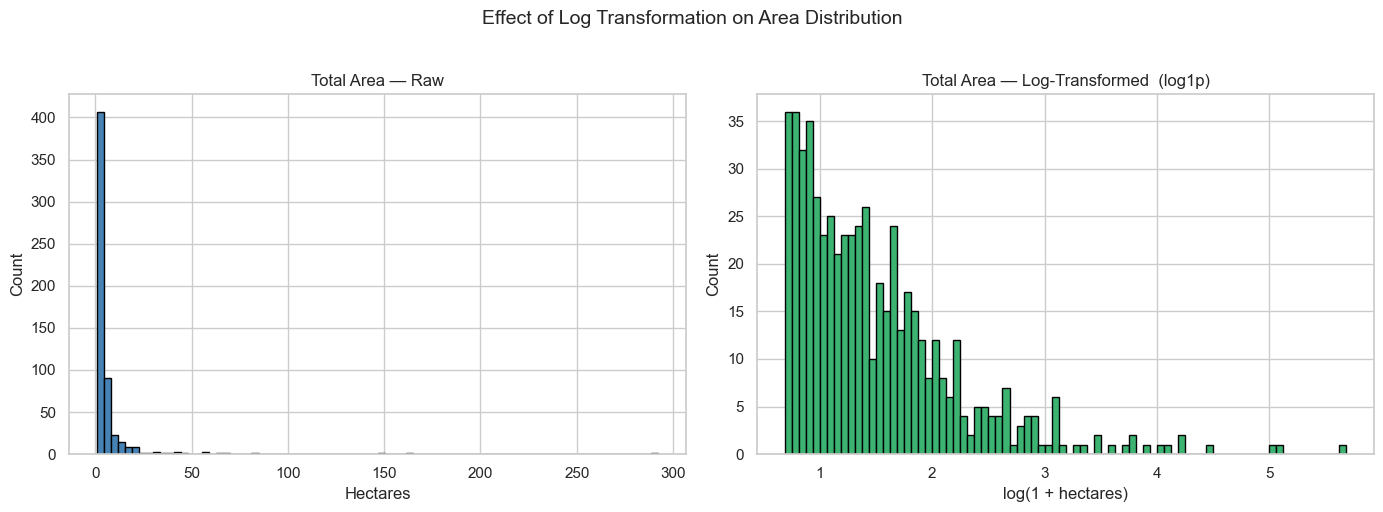

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw vs log-transformed
axes[0].hist(df["total_area_in_hectares"], bins=80, color="steelblue", edgecolor="black")
axes[0].set_title("Total Area — Raw")
axes[0].set_xlabel("Hectares")
axes[0].set_ylabel("Count")

axes[1].hist(df["log_total_area"], bins=80, color="mediumseagreen", edgecolor="black")
axes[1].set_title("Total Area — Log-Transformed  (log1p)")
axes[1].set_xlabel("log(1 + hectares)")
axes[1].set_ylabel("Count")

plt.suptitle("Effect of Log Transformation on Area Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The log transformation dramatically improves the distribution shape. The raw histogram is dominated by a single spike near zero with an invisible long tail, while the log-transformed version reveals a roughly **bell-shaped distribution** centred around log(1 + 0.6) ≈ 0.47, making statistical comparisons across groups much more meaningful.

## 14. Park Size by Classification Type

How does park area vary across the simplified classification groups?

C:\Users\QTene\AppData\Local\Temp\ipykernel_115292\3856604780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y="classification_simple", x="log_total_area",
C:\Users\QTene\AppData\Local\Temp\ipykernel_115292\3856604780.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, y="classification_simple", x="log_total_area",


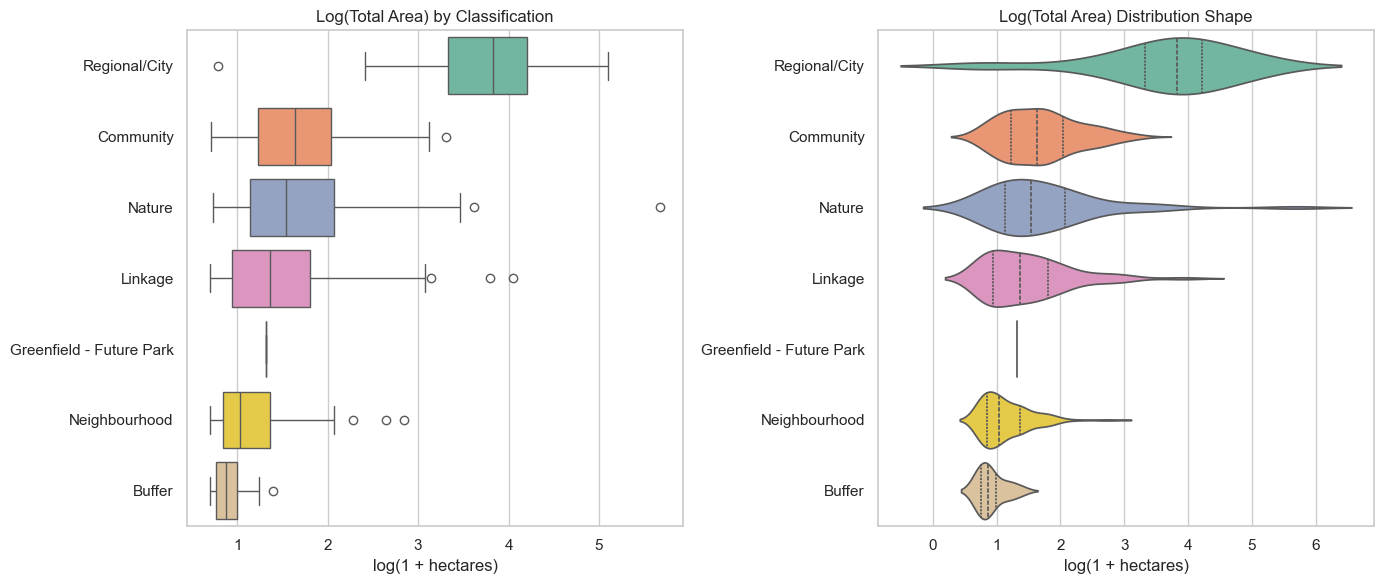

,count,median,mean,std,min,max
classification_simple,,,,,,
Regional/City,14,44.988,57.315,47.480,1.208,163.311
Community,185,4.147,5.545,4.562,1.025,26.495
Nature,43,3.640,12.778,44.252,1.069,292.202
Linkage,128,2.920,4.991,7.068,1.018,56.310
Greenfield - Future Park,1,2.730,2.730,NaN,2.730,2.730
Neighbourhood,184,1.807,2.424,1.851,1.003,16.113
Buffer,15,1.392,1.554,0.600,1.001,3.031


In [18]:
# Sort classifications by median area for clear ordering
order = (df.groupby("classification_simple")["log_total_area"]
           .median().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot on log scale
sns.boxplot(data=df, y="classification_simple", x="log_total_area",
            order=order, palette="Set2", ax=axes[0])
axes[0].set_title("Log(Total Area) by Classification")
axes[0].set_xlabel("log(1 + hectares)")
axes[0].set_ylabel("")

# Violin plot for shape detail
sns.violinplot(data=df, y="classification_simple", x="log_total_area",
               order=order, palette="Set2", inner="quartile", ax=axes[1])
axes[1].set_title("Log(Total Area) Distribution Shape")
axes[1].set_xlabel("log(1 + hectares)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Summary table
summary = (df.groupby("classification_simple")["total_area_in_hectares"]
             .agg(["count", "median", "mean", "std", "min", "max"])
             .sort_values("median", ascending=False)
             .round(3))
summary

**Observation:** Clear **size hierarchy** by classification:
- **Regional/City** and **Nature** parks are the largest (median ~2–4 ha).
- **Community** parks form a consistent mid-range group (~3–4 ha).
- **Neighbourhood**, **Linkage**, and **Buffer** parks cluster in the 0.2–1 ha range.
- **Fragment** parks are the smallest (median ~0.04 ha) — tiny leftover parcels.

The violin plots show that Linkage and Nature parks have the widest spread in size.

## 15. Water Feature Analysis

Only ~14% of parks have any water area. How are water features distributed?

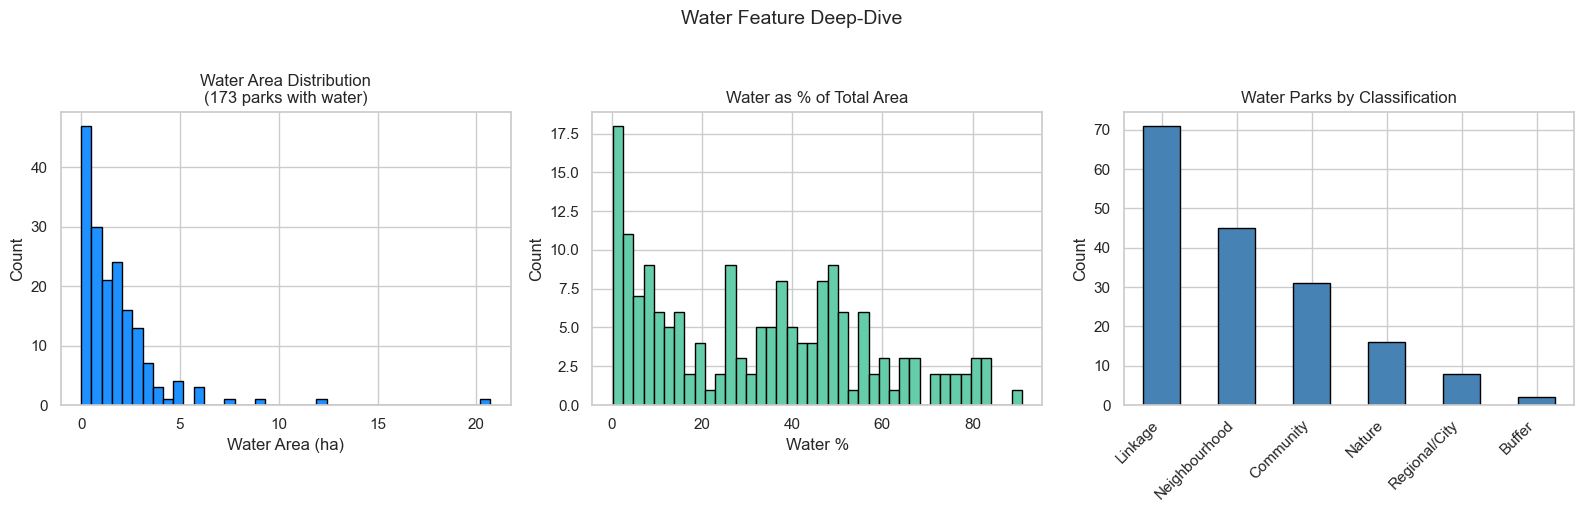

% of parks with water, by classification:
classification_simple
Regional/City               57.1
Linkage                     55.5
Nature                      37.2
Neighbourhood               24.5
Community                   16.8
Buffer                      13.3
Greenfield - Future Park     0.0


In [19]:
water_df = df[df["has_water"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribution of water area
axes[0].hist(water_df["water_area_in_hectares"], bins=40, color="dodgerblue", edgecolor="black")
axes[0].set_title(f"Water Area Distribution\n({len(water_df)} parks with water)")
axes[0].set_xlabel("Water Area (ha)")
axes[0].set_ylabel("Count")

# Water % of total area
axes[1].hist(water_df["water_pct"], bins=40, color="mediumaquamarine", edgecolor="black")
axes[1].set_title("Water as % of Total Area")
axes[1].set_xlabel("Water %")
axes[1].set_ylabel("Count")

# Water parks by classification
water_by_cls = water_df["classification_simple"].value_counts()
water_by_cls.plot(kind="bar", ax=axes[2], color="steelblue", edgecolor="black")
axes[2].set_title("Water Parks by Classification")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("")
plt.xticks(rotation=45, ha="right")

plt.suptitle("Water Feature Deep-Dive", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Water likelihood by classification
water_rate = (df.groupby("classification_simple")["has_water"]
                .mean().sort_values(ascending=False) * 100).round(1)
print("% of parks with water, by classification:")
print(water_rate.to_string())

**Observation:** Among the 194 parks with water:
- Most have **small water areas** (<2 ha), but a few outliers reach 20+ ha.
- Water typically makes up **10–40%** of total park area, with some parks being majority water.
- **Linkage** and **Neighbourhood** classifications have the most water parks by count.
- By **rate**, Nature parks are most likely to have water features, consistent with their role as natural reserves.

## 16. Park Size Bins — Breakdown by District & Classification

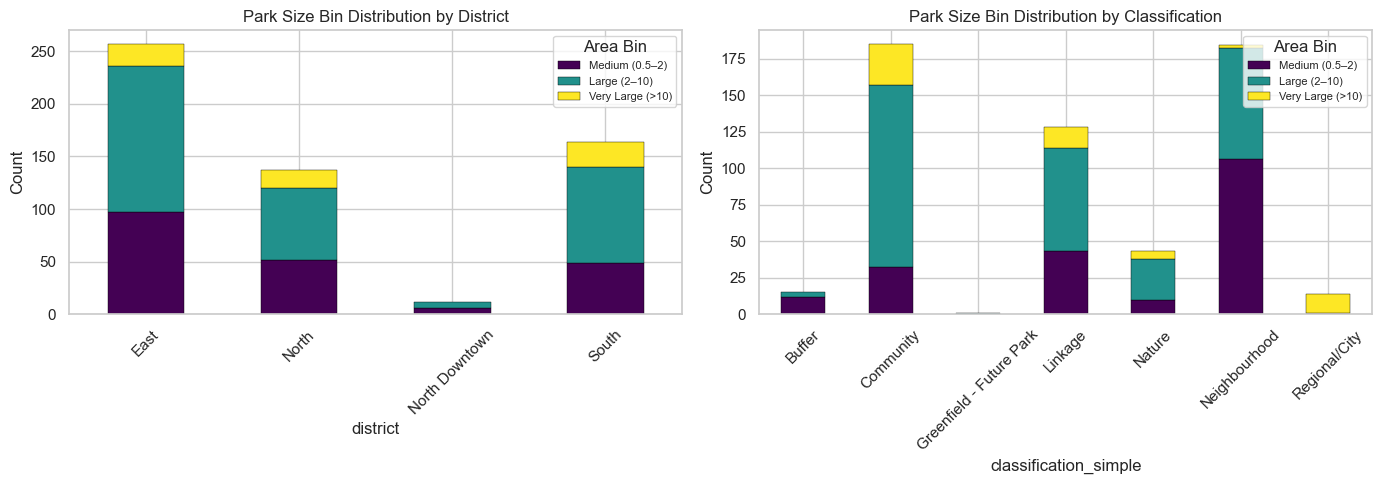

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar: area_bin by district
ct1 = pd.crosstab(df["district"], df["area_bin"])
ct1.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis", edgecolor="black", linewidth=0.3)
axes[0].set_title("Park Size Bin Distribution by District")
axes[0].set_ylabel("Count")
axes[0].legend(title="Area Bin", fontsize=8, loc="upper right")
axes[0].tick_params(axis="x", rotation=45)

# Stacked bar: area_bin by simplified classification
ct2 = pd.crosstab(df["classification_simple"], df["area_bin"])
ct2.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", edgecolor="black", linewidth=0.3)
axes[1].set_title("Park Size Bin Distribution by Classification")
axes[1].set_ylabel("Count")
axes[1].legend(title="Area Bin", fontsize=8, loc="upper right")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Observation:** The stacked bars reveal:
- **East** district has the most Tiny and Small parks, reflecting denser urban infill green spaces.
- **North Downtown** has proportionally more Large and Very Large parks.
- **Neighbourhood** and **Buffer** classifications are dominated by Tiny/Small parks.
- **Nature** and **Community** classifications contribute most of the Large/Very Large parks.

## 17. Neighbourhood-Level Aggregation — Park Density & Green Coverage

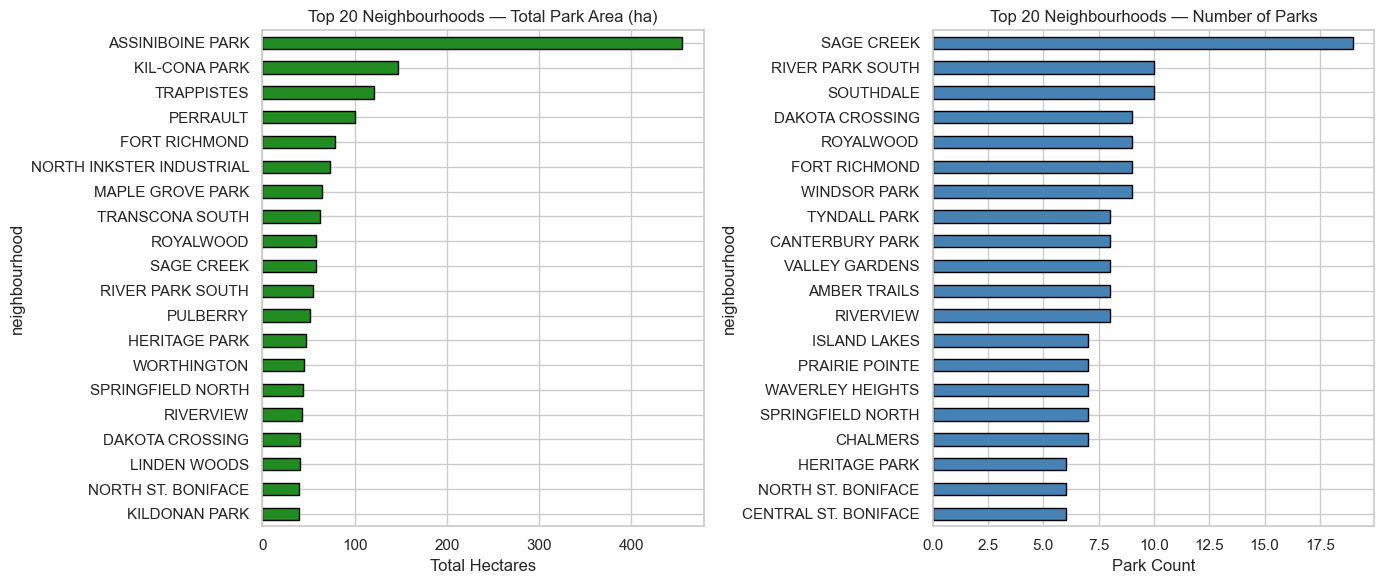

Total neighbourhoods: 183

Bottom 10 by total park area:
                     n_parks  total_ha  median_ha  has_water_pct
neighbourhood                                                   
DANIEL McINTYRE            1  1.367160   1.367160            0.0
KINGSTON CRESCENT          1  1.342106   1.342106            0.0
WEST BROADWAY              1  1.286959   1.286959            0.0
HOLDEN                     1  1.257853   1.257853            0.0
WELLINGTON CRESCENT        1  1.251162   1.251162            0.0
VICTORIA WEST              1  1.209764   1.209764            0.0
JEFFERSON                  1  1.160941   1.160941            0.0
KING EDWARD                1  1.063361   1.063361            0.0
DUFRESNE                   1  1.060336   1.060336            0.0
BURROWS CENTRAL            1  1.002975   1.002975            0.0


In [21]:
hood_stats = (df.groupby("neighbourhood")
               .agg(
                   n_parks=("park_id", "count"),
                   total_ha=("total_area_in_hectares", "sum"),
                   median_ha=("total_area_in_hectares", "median"),
                   has_water_pct=("has_water", "mean"),
               )
               .sort_values("total_ha", ascending=False))

hood_stats["has_water_pct"] = (hood_stats["has_water_pct"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 20 neighbourhoods by total green space
hood_stats.head(20)["total_ha"].plot(
    kind="barh", ax=axes[0], color="forestgreen", edgecolor="black")
axes[0].set_title("Top 20 Neighbourhoods — Total Park Area (ha)")
axes[0].set_xlabel("Total Hectares")
axes[0].invert_yaxis()

# Top 20 neighbourhoods by park count
hood_stats.sort_values("n_parks", ascending=False).head(20)["n_parks"].plot(
    kind="barh", ax=axes[1], color="steelblue", edgecolor="black")
axes[1].set_title("Top 20 Neighbourhoods — Number of Parks")
axes[1].set_xlabel("Park Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total neighbourhoods: {hood_stats.shape[0]}")
print(f"\nBottom 10 by total park area:")
print(hood_stats.tail(10).to_string())

**Observation:** Park distribution across 211 neighbourhoods is highly uneven:
- **Assiniboine Park** neighbourhood tops total area (455 ha) but has only 2 parks — one massive park skews the total.
- **Kildare-Redonda** and **River Park South** lead in park count (37 and 28).
- Bottom neighbourhoods have minimal green space (<0.1 ha total), indicating potential equity gaps in park access.

## 18. Linear Park Systems

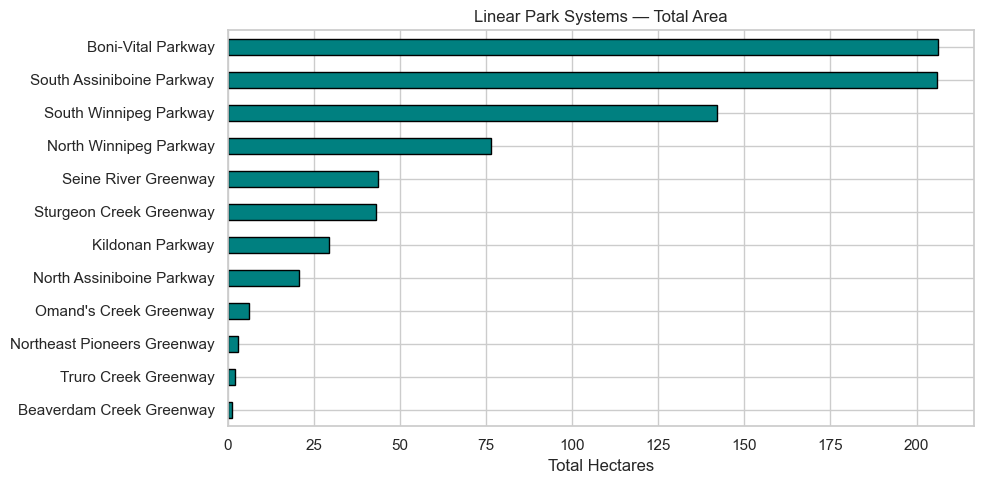

,n_parks,total_ha,avg_ha,water_parks
linear_park_system,,,,
Boni-Vital Parkway,18,206.38,11.47,1
South Assiniboine Parkway,13,205.93,15.84,3
South Winnipeg Parkway,13,142.06,10.93,2
North Winnipeg Parkway,14,76.48,5.46,6
Seine River Greenway,15,43.53,2.90,2
Sturgeon Creek Greenway,4,43.10,10.78,4
Kildonan Parkway,9,29.32,3.26,0
North Assiniboine Parkway,5,20.61,4.12,2
Omand's Creek Greenway,3,6.19,2.06,3


In [22]:
linear_df = df[df["is_on_linear_system"]]

lps_stats = (linear_df.groupby("linear_park_system")
               .agg(
                   n_parks=("park_id", "count"),
                   total_ha=("total_area_in_hectares", "sum"),
                   avg_ha=("total_area_in_hectares", "mean"),
                   water_parks=("has_water", "sum"),
               )
               .sort_values("total_ha", ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
lps_stats[["total_ha"]].plot(kind="barh", ax=ax, color="teal", edgecolor="black", legend=False)
ax.set_title("Linear Park Systems — Total Area")
ax.set_xlabel("Total Hectares")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

lps_stats.round(2)

**Observation:** The 12 linear park systems vary greatly in scale:
- **Boni-Vital Parkway** has the largest total footprint, while **Seine River Greenway** has the most individual park segments (43).
- Several greenways include parks with water features, reflecting their river/creek corridor nature.
- Half of the systems have fewer than 10 parks, representing smaller neighbourhood connectors.

## 19. District Comparison — Multi-Metric View

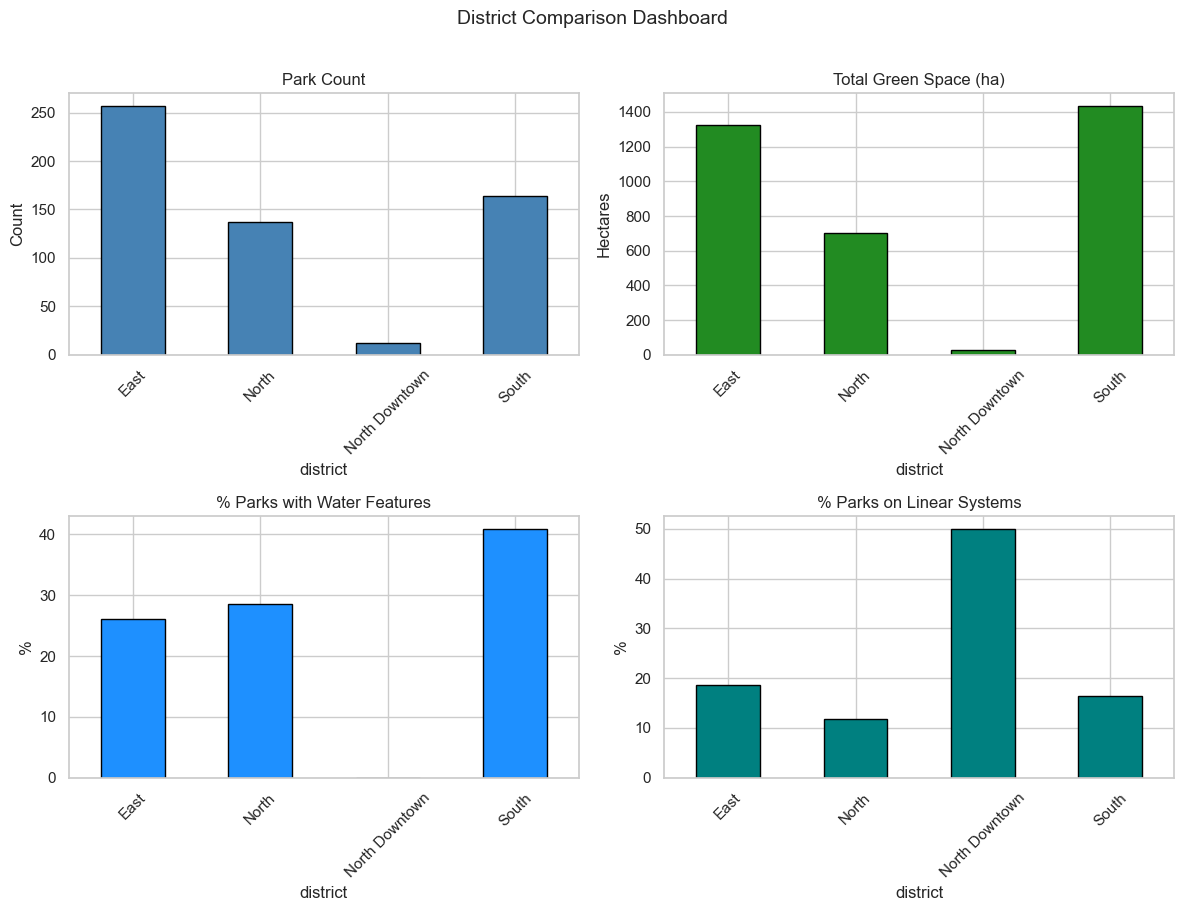

,n_parks,total_ha,median_ha,pct_water,pct_linear,n_hoods
district,,,,,,
East,257,1327.11,2.59,26.1,18.7,63
North,137,701.25,2.66,28.5,11.7,55
North Downtown,12,24.76,2.11,0.0,50.0,10
South,164,1435.35,3.48,40.9,16.5,56


In [23]:
district_stats = (df.groupby("district")
                    .agg(
                        n_parks=("park_id", "count"),
                        total_ha=("total_area_in_hectares", "sum"),
                        median_ha=("total_area_in_hectares", "median"),
                        pct_water=("has_water", "mean"),
                        pct_linear=("is_on_linear_system", "mean"),
                        n_hoods=("neighbourhood", "nunique"),
                    ))
district_stats["pct_water"] = (district_stats["pct_water"] * 100).round(1)
district_stats["pct_linear"] = (district_stats["pct_linear"] * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

district_stats["n_parks"].plot(kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black")
axes[0, 0].set_title("Park Count")
axes[0, 0].set_ylabel("Count")

district_stats["total_ha"].plot(kind="bar", ax=axes[0, 1], color="forestgreen", edgecolor="black")
axes[0, 1].set_title("Total Green Space (ha)")
axes[0, 1].set_ylabel("Hectares")

district_stats["pct_water"].plot(kind="bar", ax=axes[1, 0], color="dodgerblue", edgecolor="black")
axes[1, 0].set_title("% Parks with Water Features")
axes[1, 0].set_ylabel("%")

district_stats["pct_linear"].plot(kind="bar", ax=axes[1, 1], color="teal", edgecolor="black")
axes[1, 1].set_title("% Parks on Linear Systems")
axes[1, 1].set_ylabel("%")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("District Comparison Dashboard", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

district_stats.round(2)

**Observation:** District dashboard highlights:
- **East** leads in both park count (569) and total green space.
- **South** has the highest % of parks with water features and parks on linear systems, reflecting its river corridor geography.
- **North Downtown** has the fewest parks but notable median size — fewer, larger community spaces.
- Water feature and linear system rates are lowest in the **North** district.

## 20. Geospatial Scatter — Coloured by Classification & District

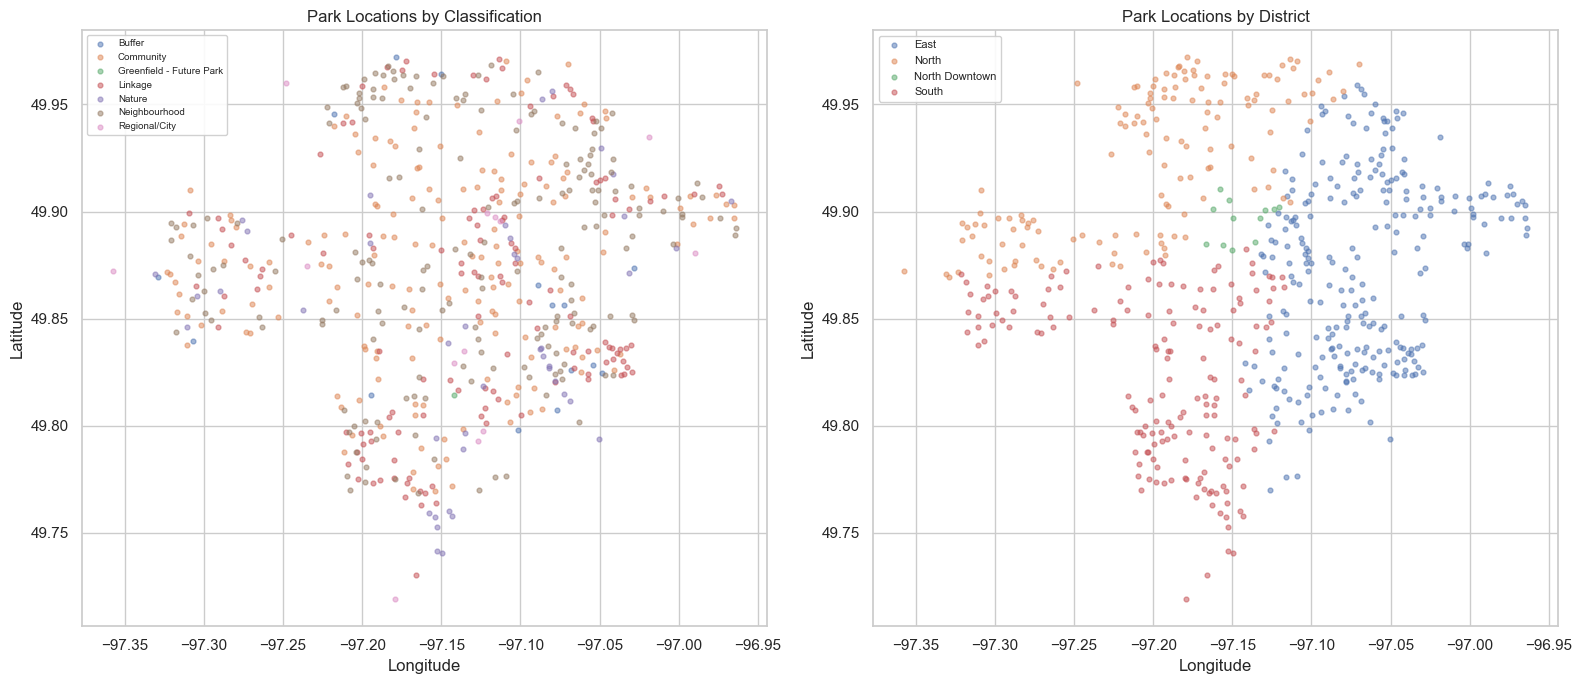

In [24]:
geo = df.dropna(subset=["lat", "lon"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# By classification
for cls, grp in geo.groupby("classification_simple"):
    axes[0].scatter(grp["lon"], grp["lat"], label=cls, alpha=0.5, s=12)
axes[0].set_title("Park Locations by Classification")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(fontsize=7, loc="upper left", framealpha=0.9)

# By district
for dist, grp in geo.groupby("district"):
    axes[1].scatter(grp["lon"], grp["lat"], label=dist, alpha=0.5, s=12)
axes[1].set_title("Park Locations by District")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(fontsize=8, loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

**Observation:** Geospatial patterns:
- **Classification map**: Linkage parks (green corridors) trace along waterways; Neighbourhood parks are evenly spread across the city; Nature parks cluster at the edges.
- **District map**: The four districts form clear **geographic quadrants** — East/North/South/North Downtown — with boundaries roughly aligned to the Red and Assiniboine rivers.

## 21. Electoral Ward Comparison — Park Count & Median Size

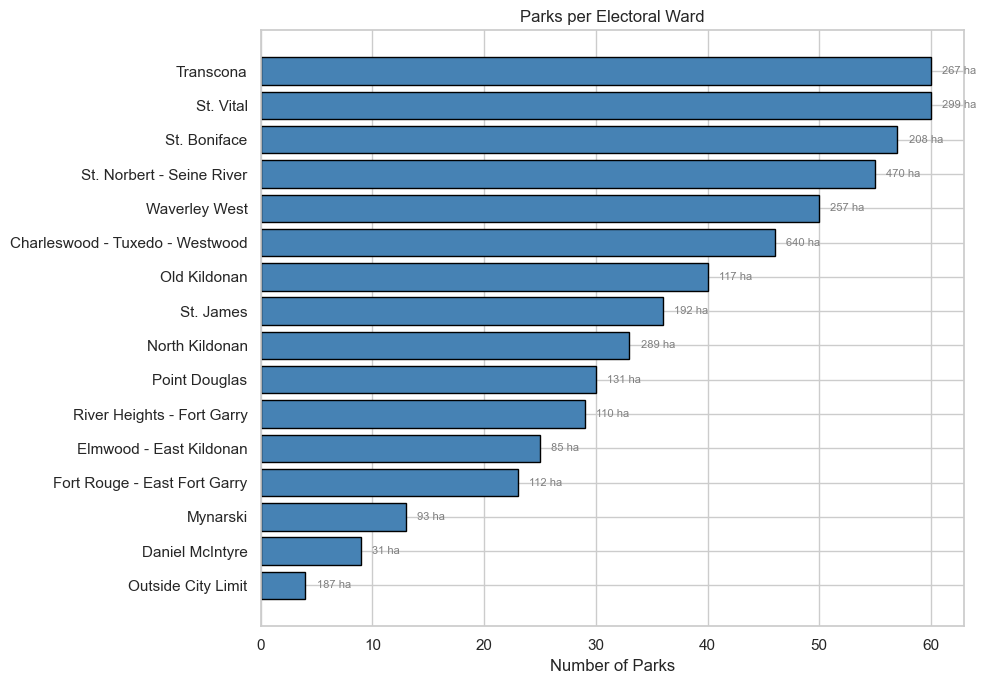

In [25]:
ward_stats = (df.groupby("electoral_ward")
               .agg(
                   n_parks=("park_id", "count"),
                   total_ha=("total_area_in_hectares", "sum"),
                   median_ha=("total_area_in_hectares", "median"),
               )
               .sort_values("n_parks", ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(ward_stats))
ax.barh(y, ward_stats["n_parks"], color="steelblue", edgecolor="black", label="Park Count")
ax.set_yticks(y)
ax.set_yticklabels(ward_stats.index)
ax.set_xlabel("Number of Parks")
ax.set_title("Parks per Electoral Ward")

# Annotate total hectares
for i, (cnt, ha) in enumerate(zip(ward_stats["n_parks"], ward_stats["total_ha"])):
    ax.text(cnt + 1, i, f"{ha:.0f} ha", va="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

**Observation:** Electoral ward comparison reveals:
- **Transcona** (144 parks) and **St. Vital** (123) top both park count and total hectares.
- **Daniel McIntyre** has the fewest parks (42), reflecting its older, denser urban character.
- Total hectares vary more than park count — some wards have many tiny parks while others have fewer but larger ones.
- **Outside City Limit** is a minor category with only 5 parks.

## 22. Pair Plot — Numerical Features (log-scale) by Classification

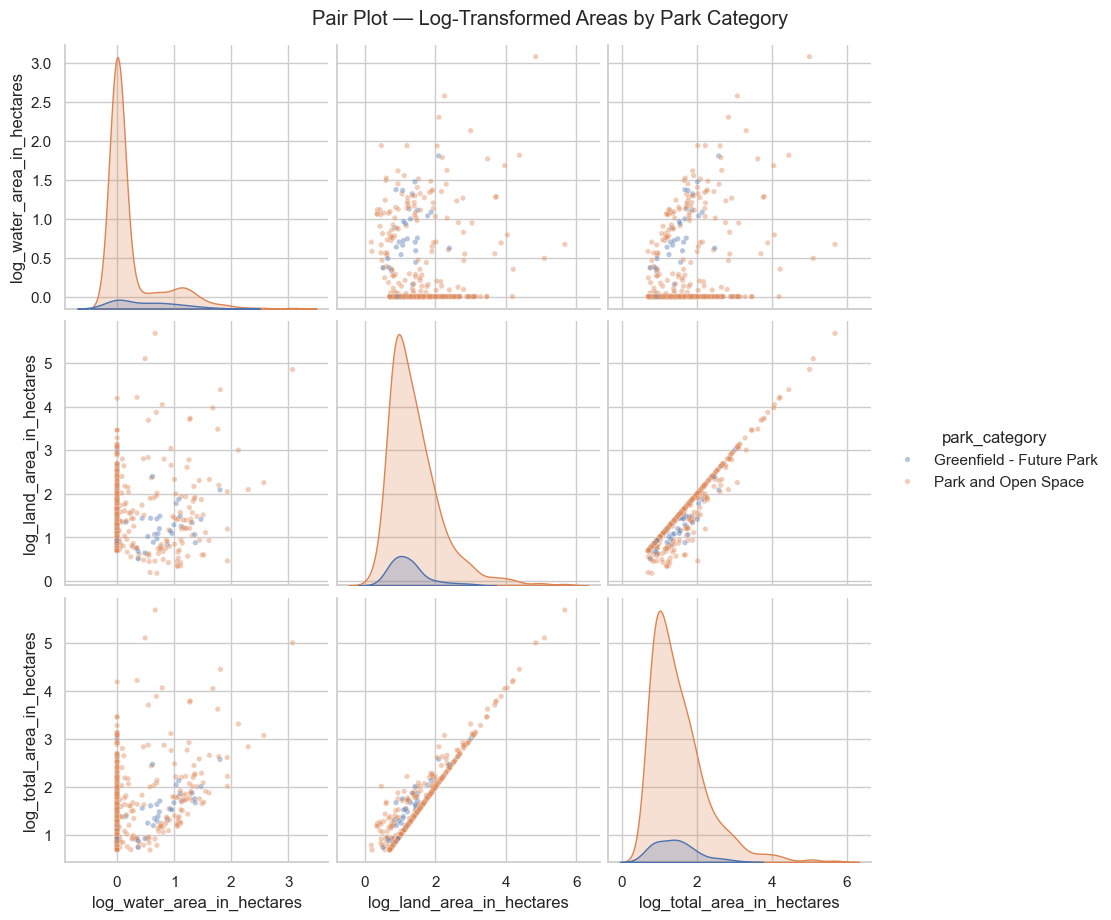

In [ ]:
# Use log-transformed columns for better visibility
plot_df = df[["classification_simple", "water_area_in_hectares", "land_area_in_hectares", "total_area_in_hectares"]].copy()
for c in ["water_area_in_hectares", "land_area_in_hectares", "total_area_in_hectares"]:
    plot_df[f"log_{c}"] = np.log1p(plot_df[c])

g = sns.pairplot(
    plot_df,
    vars=["log_water_area_in_hectares", "log_land_area_in_hectares", "log_total_area_in_hectares"],
    hue="classification_simple",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    height=3,
)
g.figure.suptitle("Pair Plot — Log-Transformed Areas by Classification", y=1.02)
plt.show()

**Observation:** The pair plot confirms:
- **log(land)** and **log(total)** are nearly perfectly linear — land area dominates total area for most parks.
- **log(water)** shows a floor at zero (most parks have no water) and a weak positive relationship with total area.
- **Nature** and **Regional/City** classifications separate clearly in the upper range, while **Neighbourhood** and **Linkage** parks cluster in the lower-mid range.

## 23. Summary of Key Findings

| Finding | Detail |
|---------|--------|
| **Dataset** | 1,388 parks across 4 districts, 16 electoral wards, 211 neighbourhoods |
| **Cleaning** | Fixed 1 typo, filled 1,198 nulls, flagged 6 multi-parcel rows, dropped parks < 1 ha, dropped Greenfield/Future parks |
| **Size distribution** | Heavily right-skewed — median ~0.65 ha, mean ~2.7 ha, max 292 ha |
| **Classification hierarchy** | Nature & Regional parks are largest; Fragment & Buffer are smallest |
| **Water** | 14% of parks have water features; Nature parks have highest water rate |
| **Linear systems** | 190 parks span 12 named greenways/parkways; Seine River Greenway is the largest |
| **Geospatial** | East district has the most parks; districts form clean geographic clusters |